# Bank Customer Churn Analysis

## Project Objective

Customer churn directly affects customer lifetime value and long-term revenue.  
The objective of this analysis is to identify the major factors associated with customer churn and determine which customer segments are at the highest risk of leaving the bank.

### Key Questions

- What is the overall customer churn rate?
- Which customer segments have the highest churn?
- Does geography influence churn?
- How does customer activity affect churn?
- Which age groups are most likely to churn?
- Does the number of bank products influence customer retention?
- How do tenure, gender, balance, and credit score relate to churn?

### Analysis Workflow

1. Data Understanding
2. Data Cleaning
3. Exploratory Data Analysis
4. Customer Churn Analysis
5. Feature Engineering
6. Business Insights & Recommendations

> **Note:** Machine-learning experimentation is intentionally kept outside this project notebook. This notebook focuses on the analytical and business-intelligence workflow.


In [1]:
import os

print(os.getcwd())

c:\Users\vaidi\OneDrive\Desktop\Bank Data Analyser\notebooks


## 1. Imports

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)


## 2. Data Understanding

In [3]:
# Load the original dataset
df = pd.read_csv("../data/churn_raw.csv")

df.head()


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [4]:
df.shape

(10000, 14)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [6]:
df.isnull().sum()

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(0)

### Initial Observations

The dataset contains customer demographic, financial, and engagement-related variables along with the target variable `Exited`.

Before analysis, the dataset is checked for:

- Missing values
- Duplicate records
- Irrelevant identifier columns
- Incorrect data types


## 3. Data Cleaning

In [8]:
# Create a separate cleaned copy
df_clean = df.copy()

# Remove identifier columns that do not contribute to customer-behaviour analysis
columns_to_drop = ["RowNumber", "CustomerId", "Surname"]
df_clean = df_clean.drop(columns=columns_to_drop)

df_clean.head()


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [9]:
print("Missing values:", df_clean.isnull().sum().sum())
print("Duplicate rows:", df_clean.duplicated().sum())
print("Final shape:", df_clean.shape)


Missing values: 0
Duplicate rows: 0
Final shape: (10000, 11)


### 3.1 Feature Engineering

In [10]:
# Age segmentation
df_clean["AgeGroup"] = pd.cut(
    df_clean["Age"],
    bins=[0, 30, 40, 50, 60, 100],
    labels=["18-30", "31-40", "41-50", "51-60", "60+"]
)

# Balance segmentation
df_clean["BalanceCategory"] = pd.cut(
    df_clean["Balance"],
    bins=[-1, 0, 10000, 50000, 100000, np.inf],
    labels=["Zero", "Low", "Medium", "High", "Very High"]
)

# Tenure segmentation
df_clean["TenureGroup"] = pd.cut(
    df_clean["Tenure"],
    bins=[-1, 2, 5, 10],
    labels=["New (0-2 yrs)", "Medium (3-5 yrs)", "Long (6-10 yrs)"]
)

df_clean[["Age", "AgeGroup", "Balance", "BalanceCategory", "Tenure", "TenureGroup"]].head()


,Age,AgeGroup,Balance,BalanceCategory,Tenure,TenureGroup
0,42,41-50,0.00,Zero,2,New (0-2 yrs)
1,41,41-50,83807.86,High,1,New (0-2 yrs)
2,42,41-50,159660.80,Very High,8,Long (6-10 yrs)
3,39,31-40,0.00,Zero,1,New (0-2 yrs)
4,43,41-50,125510.82,Very High,2,New (0-2 yrs)


In [11]:
# Save cleaned data for SQL / Power BI analysis
df_clean.to_csv("../data/churn_cleaned.csv", index=False)


## 4. Exploratory Data Analysis

The exploratory analysis focuses on customer characteristics and behavioural factors associated with churn.

For categorical variables, the mean of `Exited` is used as the churn rate because:

- `Exited = 0` → customer stayed
- `Exited = 1` → customer churned


### 4.1 Overall Churn Rate

In [12]:
total_customers = len(df_clean)
churned_customers = int(df_clean["Exited"].sum())
churn_rate = df_clean["Exited"].mean() * 100

print(f"Total Customers: {total_customers:,}")
print(f"Churned Customers: {churned_customers:,}")
print(f"Overall Churn Rate: {churn_rate:.2f}%")


Total Customers: 10,000
Churned Customers: 2,037
Overall Churn Rate: 20.37%


**Insight:** Approximately **20.37%** of customers in the dataset churned, meaning roughly one in every five customers exited the bank.

### 4.2 Churn by Geography

In [13]:
geo_churn = (
    df_clean.groupby("Geography", observed=False)["Exited"]
    .agg(Total_Customers="count", Churned_Customers="sum", Churn_Rate="mean")
    .reset_index()
)

geo_churn["Churn_Rate"] *= 100
geo_churn = geo_churn.sort_values("Churn_Rate", ascending=False)

geo_churn


,Geography,Total_Customers,Churned_Customers,Churn_Rate
1,Germany,2509,814,32.443204
2,Spain,2477,413,16.673395
0,France,5014,810,16.154767


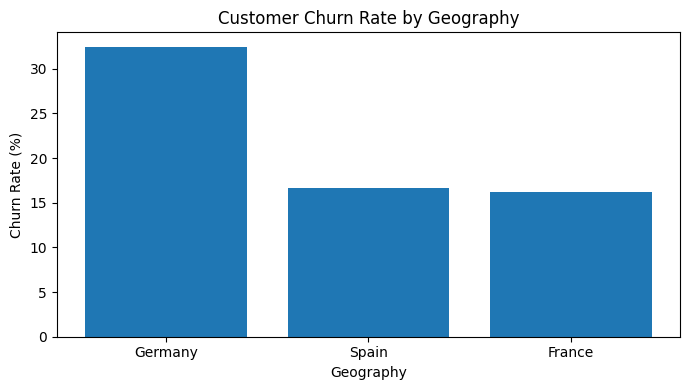

In [29]:
plt.figure(figsize=(7, 4))
plt.bar(geo_churn["Geography"], geo_churn["Churn_Rate"])
plt.title("Customer Churn Rate by Geography")
plt.xlabel("Geography")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(
    "../visualizations/churn_by_geography.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


**Insight:** Germany has the highest churn rate at approximately **32.4%**, almost twice the rate observed in France and Spain. Germany should therefore receive priority in deeper retention analysis.

### 4.3 Churn by Age Group

In [15]:
age_churn = (
    df_clean.groupby("AgeGroup", observed=False)["Exited"]
    .agg(Total_Customers="count", Churned_Customers="sum", Churn_Rate="mean")
    .reset_index()
)

age_churn["Churn_Rate"] *= 100
age_churn.sort_values("Churn_Rate", ascending=False)


,AgeGroup,Total_Customers,Churned_Customers,Churn_Rate
3,51-60,797,448,56.210790
2,41-50,2320,788,33.965517
4,60+,464,115,24.784483
1,31-40,4451,538,12.087171
0,18-30,1968,148,7.520325


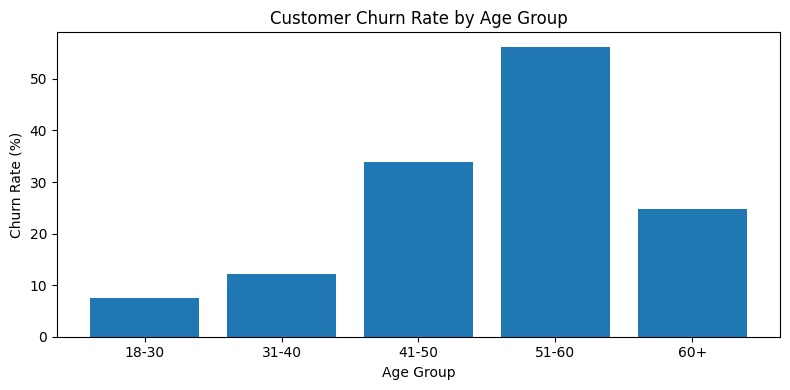

In [30]:
plt.figure(figsize=(8, 4))
plt.bar(age_churn["AgeGroup"].astype(str), age_churn["Churn_Rate"])
plt.title("Customer Churn Rate by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(
    "../visualizations/churn_by_age_group.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


**Insight:** The **51–60** age group has the highest churn rate, followed by the **41–50** group. Churn risk increases strongly through middle age before falling again among the oldest segment.

### 4.4 Active Membership vs Churn

In [17]:
activity_churn = (
    df_clean.groupby("IsActiveMember")["Exited"]
    .agg(Total_Customers="count", Churned_Customers="sum", Churn_Rate="mean")
    .reset_index()
)

activity_churn["Member_Status"] = activity_churn["IsActiveMember"].map({
    0: "Inactive",
    1: "Active"
})
activity_churn["Churn_Rate"] *= 100

activity_churn[["Member_Status", "Total_Customers", "Churned_Customers", "Churn_Rate"]]


,Member_Status,Total_Customers,Churned_Customers,Churn_Rate
0,Inactive,4849,1302,26.850897
1,Active,5151,735,14.269074


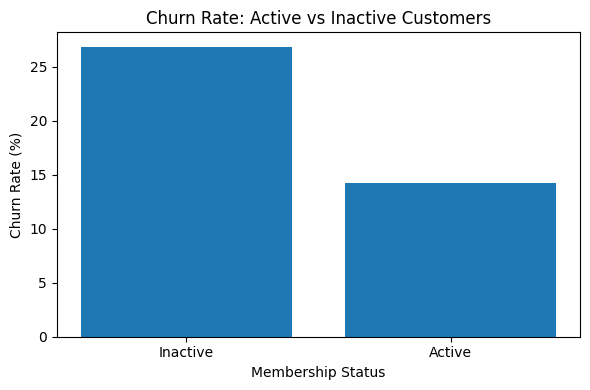

In [31]:
plt.figure(figsize=(6, 4))
plt.bar(activity_churn["Member_Status"], activity_churn["Churn_Rate"])
plt.title("Churn Rate: Active vs Inactive Customers")
plt.xlabel("Membership Status")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(
    "../visualizations/churn_by_activity.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


**Insight:** Inactive customers churn at roughly **26.9%**, compared with about **14.3%** for active customers. Customer engagement is therefore one of the clearest retention indicators in the dataset.

### 4.5 Churn by Tenure

In [19]:
tenure_churn = (
    df_clean.groupby("TenureGroup", observed=False)["Exited"]
    .agg(Total_Customers="count", Churned_Customers="sum", Churn_Rate="mean")
    .reset_index()
)

tenure_churn["Churn_Rate"] *= 100
tenure_churn


,TenureGroup,Total_Customers,Churned_Customers,Churn_Rate
0,New (0-2 yrs),2496,528,21.153846
1,Medium (3-5 yrs),3010,625,20.764120
2,Long (6-10 yrs),4494,884,19.670672


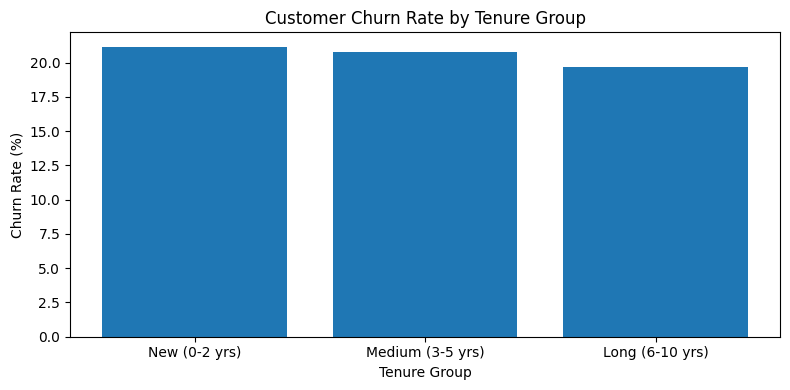

In [32]:
plt.figure(figsize=(8, 4))
plt.bar(tenure_churn["TenureGroup"].astype(str), tenure_churn["Churn_Rate"])
plt.title("Customer Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(
    "../visualizations/churn_by_tenure.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


**Insight:** Churn declines slightly as tenure increases. Newer customers show the highest churn, although the difference between tenure groups is much smaller than the differences seen for geography, age, or customer activity.

### 4.6 Churn by Number of Products

In [21]:
product_churn = (
    df_clean.groupby("NumOfProducts")["Exited"]
    .agg(Total_Customers="count", Churned_Customers="sum", Churn_Rate="mean")
    .reset_index()
)

product_churn["Churn_Rate"] *= 100
product_churn


,NumOfProducts,Total_Customers,Churned_Customers,Churn_Rate
0,1,5084,1409,27.714398
1,2,4590,348,7.581699
2,3,266,220,82.706767
3,4,60,60,100.000000


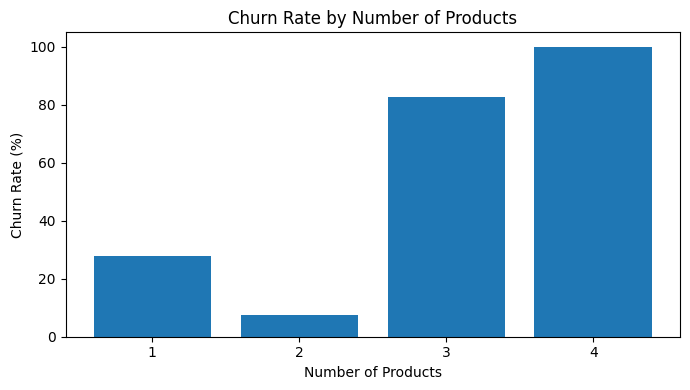

In [33]:
plt.figure(figsize=(7, 4))
plt.bar(product_churn["NumOfProducts"].astype(str), product_churn["Churn_Rate"])
plt.title("Churn Rate by Number of Products")
plt.xlabel("Number of Products")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(
    "../visualizations/churn_by_products.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


**Insight:** Customers with **3 or 4 products** show disproportionately high churn. This is counter-intuitive and should be investigated for possible product complexity, fees, bundling friction, or service issues.

### 4.7 Churn by Gender

In [23]:
gender_churn = (
    df_clean.groupby("Gender")["Exited"]
    .agg(Total_Customers="count", Churned_Customers="sum", Churn_Rate="mean")
    .reset_index()
)

gender_churn["Churn_Rate"] *= 100
gender_churn


,Gender,Total_Customers,Churned_Customers,Churn_Rate
0,Female,4543,1139,25.071539
1,Male,5457,898,16.455928


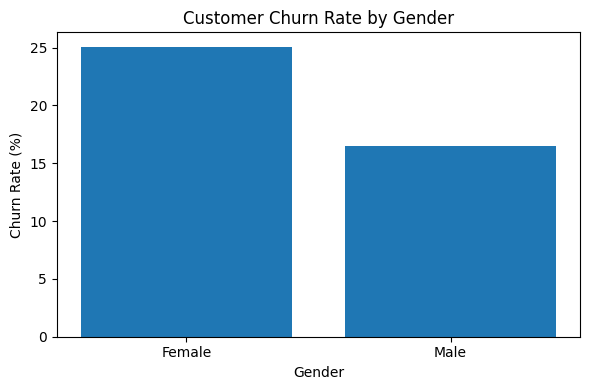

In [34]:
plt.figure(figsize=(6, 4))
plt.bar(gender_churn["Gender"], gender_churn["Churn_Rate"])
plt.title("Customer Churn Rate by Gender")
plt.xlabel("Gender")
plt.ylabel("Churn Rate (%)")
plt.tight_layout()
plt.savefig(
    "../visualizations/churn_by_gender.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### 4.8 Balance Category vs Churn

In [25]:
balance_churn = (
    df_clean.groupby("BalanceCategory", observed=False)["Exited"]
    .agg(Total_Customers="count", Churned_Customers="sum", Churn_Rate="mean")
    .reset_index()
)

balance_churn["Churn_Rate"] *= 100
balance_churn


,BalanceCategory,Total_Customers,Churned_Customers,Churn_Rate
0,Zero,3617,500,13.823611
1,Low,1,1,100.000000
2,Medium,74,25,33.783784
3,High,1509,300,19.880716
4,Very High,4799,1211,25.234424


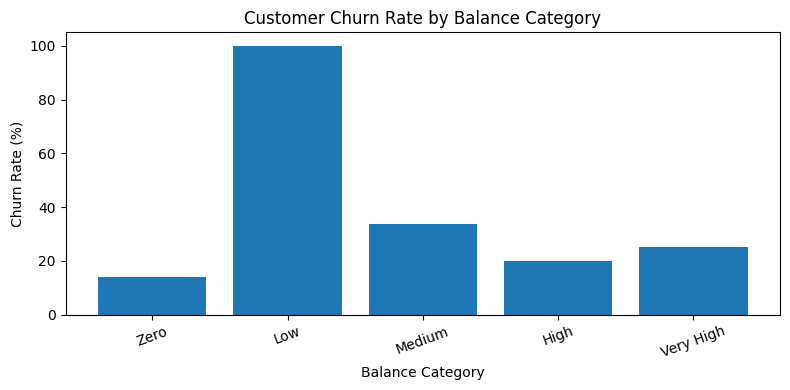

In [35]:
plt.figure(figsize=(8, 4))
plt.bar(balance_churn["BalanceCategory"].astype(str), balance_churn["Churn_Rate"])
plt.title("Customer Churn Rate by Balance Category")
plt.xlabel("Balance Category")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=20)
plt.tight_layout()
plt.savefig(
    "../visualizations/churn_by_balance.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


### 4.9 Credit Card Ownership vs Churn

In [27]:
card_churn = (
    df_clean.groupby("HasCrCard")["Exited"]
    .agg(Total_Customers="count", Churned_Customers="sum", Churn_Rate="mean")
    .reset_index()
)

card_churn["Card_Status"] = card_churn["HasCrCard"].map({
    0: "No Credit Card",
    1: "Has Credit Card"
})
card_churn["Churn_Rate"] *= 100

card_churn[["Card_Status", "Total_Customers", "Churned_Customers", "Churn_Rate"]]


,Card_Status,Total_Customers,Churned_Customers,Churn_Rate
0,No Credit Card,2945,613,20.814941
1,Has Credit Card,7055,1424,20.184266


## 5. High-Risk Customer Segmentation

Individual factors are useful, but retention teams need combined customer segments.  
The following analysis identifies customers who simultaneously display multiple high-risk characteristics.


In [28]:
high_risk_customers = df_clean[
    (df_clean["Geography"] == "Germany") &
    (df_clean["IsActiveMember"] == 0) &
    (df_clean["Age"].between(41, 60))
]

print(f"High-risk customers identified: {len(high_risk_customers):,}")
print(f"Churn rate in this segment: {high_risk_customers['Exited'].mean() * 100:.2f}%")

high_risk_customers.head()


High-risk customers identified: 501
Churn rate in this segment: 64.47%


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,AgeGroup,BalanceCategory,TenureGroup
16,653,Germany,Male,58,1,132602.88,1,1,0,5097.67,1,51-60,Very High,New (0-2 yrs)
32,553,Germany,Male,41,9,110112.54,2,0,0,81898.81,0,41-50,Very High,Long (6-10 yrs)
50,698,Germany,Male,44,10,116363.37,2,1,0,198059.16,0,41-50,Very High,Long (6-10 yrs)
53,655,Germany,Male,41,8,125561.97,1,0,0,164040.94,1,41-50,Very High,Long (6-10 yrs)
54,601,Germany,Male,42,1,98495.72,1,1,0,40014.76,1,41-50,High,New (0-2 yrs)


## 6. Summary of Key Findings

The analysis highlights several clear churn patterns:

- **Overall churn is approximately 20.37%.**
- **Germany** has the highest geographic churn rate at roughly **32.4%**.
- **Inactive customers** churn substantially more than active customers.
- The **51–60 age group** has the highest churn rate, followed by customers aged **41–50**.
- Churn decreases slightly as **tenure** increases.
- Customers with **3–4 products** show unusually high churn and warrant investigation.
- Combining geography, inactivity, and age produces a useful high-risk segment for targeted retention activity.

These findings suggest that churn is associated more strongly with customer engagement and segment characteristics than with any single financial variable.


## 7. Business Recommendations

### 1. Prioritize German Customer Retention
Germany's churn rate is substantially higher than France and Spain. The bank should investigate region-specific factors such as pricing, competitor activity, service experience, and product suitability.

### 2. Re-engage Inactive Customers
Inactive members have a much higher churn rate. Behaviour-triggered engagement campaigns, personalized offers, and proactive service outreach should focus on customers showing declining activity.

### 3. Target High-Risk Middle-Aged Customers
Customers aged 41–60, especially those in the 51–60 group, should receive more proactive retention attention where commercially appropriate.

### 4. Investigate Product Friction
Customers holding three or four products show unusually high churn. Product bundles, fees, service complexity, and cross-selling practices should be reviewed.

### 5. Use Combined Risk Segments
Retention campaigns should not rely on a single feature. Combining location, activity, age, product usage, and balance characteristics can help prioritize customers for intervention.


## 8. Limitations and Next Steps

### Limitations

- The dataset is a static snapshot and does not contain transaction-level behavioural history.
- Correlation between a customer characteristic and churn does not establish causation.
- No information is available about competitor offers, service complaints, pricing changes, or customer satisfaction.
- Financial impact estimates would require more detailed revenue and profitability data.

### Next Steps

- Connect the cleaned dataset to Power BI for an executive-facing churn dashboard.
- Validate key business findings using SQL queries.
- Perform separate machine-learning experimentation on the cleaned dataset to estimate churn probability.
- If richer behavioural data becomes available, introduce transaction frequency, engagement trends, and service-interaction features.
